Softmax Function

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# SOFTMAX FUNCTION
def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)  # Numerical stability
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Test case for Softmax Function

In [14]:
# Test
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")



Softmax function passed the test case!


Predict Function

In [15]:
# PREDICT FUNCTION
def predict_softmax(X, W, b):
    z = X @ W + b               # Logits:       shape (n, c)
    probs = softmax(z)           # Probabilities: shape (n, c)
    predicted_classes = np.argmax(probs, axis=1)  # shape (n,)
    return predicted_classes



Test case for Predict function

In [16]:
# Test
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


Loss Functions

In [18]:

# LOSS FUNCTION (single or batch)
def loss_softmax(y_pred, y):
   # Avoid log(0)
    y_pred = np.clip(y_pred, 1e-15, 1.0)
    # Cross-entropy
    loss = -np.sum(y * np.log(y_pred))
    return loss




Test case for Loss function

In [19]:
# Test
y_true_correct   = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_pred_correct   = np.array([[0.9,0.05,0.05],[0.1,0.85,0.05],[0.05,0.1,0.85]])
y_pred_incorrect = np.array([[0.05,0.05,0.9],[0.1,0.05,0.85],[0.85,0.1,0.05]])

loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, \
    f"Test failed: {loss_correct:.4f} >= {loss_incorrect:.4f}"
print(f" Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f" Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

 Cross-Entropy Loss (Correct Predictions):   0.4304
 Cross-Entropy Loss (Incorrect Predictions): 8.9872


Cost Function

In [21]:
# COST FUNCTION (average over all samples)
def cost_softmax(X, y, W, b):
    n = X.shape[0]
    z      = X @ W + b
    y_pred = softmax(z)
    y_pred = np.clip(y_pred, 1e-15, 1.0)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n



Test case for Cost function

In [22]:
# Test
X_correct   = np.array([[1.0,0.0],[0.0,1.0]])
y_correct   = np.array([[1,0],[0,1]])
W_correct   = np.array([[5.0,-2.0],[-3.0,5.0]])
b_correct   = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1,0.9],[0.8,0.2]])
y_incorrect = np.array([[1,0],[0,1]])
W_incorrect = np.array([[0.1,2.0],[1.5,0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, \
    f"Test failed: {cost_incorrect} is not > {cost_correct}"
print(f"Cost for correct prediction:   {cost_correct:.4f}")
print(f"Cost for incorrect prediction: {cost_incorrect:.4f}")
print("Test passed!")



Cost for correct prediction:   0.0006
Cost for incorrect prediction: 0.2993
Test passed!


Gradient And Gradient Descent

In [24]:

# COMPUTE GRADIENTS
def compute_gradient_softmax(X, y, W, b):
    n      = X.shape[0]
    z      = X @ W + b
    y_pred = softmax(z)
    error  = y_pred - y                          # shape (n, c)
    grad_W = (X.T @ error) / n                   # shape (d, c)
    grad_b = np.mean(error, axis=0)              # shape (c,)
    return grad_W, grad_b


Test case for Gradient

In [31]:
# Test
X_test = np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]])
y_test = np.array([[1,0,0],[0,1,0],[0,0,1]])
W_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test     = np.dot(X_test, W_test) + b_test
y_pred_t   = softmax(z_test)
grad_W_man = np.dot(X_test.T, (y_pred_t - y_test)) / X_test.shape[0]
grad_b_man = np.sum(y_pred_t - y_test, axis=0)  / X_test.shape[0]

assert np.allclose(grad_W, grad_W_man), "Gradient W mismatch!"
assert np.allclose(grad_b, grad_b_man), "Gradient b mismatch!"
print("Gradient w.r.t. W:\n", grad_W)
print("\nGradient w.r.t. b:\n", grad_b)
print("\nTest passed!")


Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]

Gradient w.r.t. b:
 [-0.03290036  0.02484708  0.00805328]

Test passed!


Gradient Descent

In [27]:
# GRADIENT DESCENT
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Track cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Print every 100 iterations
        if show_cost and i % 100 == 0:
            print(f"Iteration {i:4d} | Cost: {cost:.6f}")

    return W, b, cost_history

Load And Prepare MNIST Dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


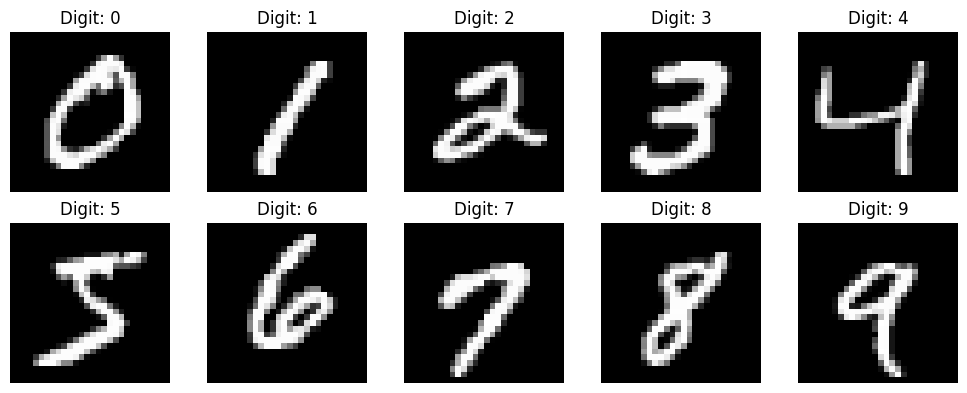

Dimensions matched — ready to train!


In [37]:
# LOAD AND PREPARE MNIST
# ─── Mount Drive and Load ────────────────
from google.colab import drive
drive.mount('/content/drive')

csv_file_path = "/content/drive/MyDrive/AI And ML/mnist_dataset_2025.csv"
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file_path)

# Shape check
assert len(X_train) == len(y_train), "Shape mismatch!"
print("Dimensions matched — ready to train!")
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df = pd.read_csv(csv_file)


    y = df.iloc[:, 0].values        # Labels
    X = df.iloc[:, 1:].values       # Pixel values

    X = X / 255.0                   # Normalize to [0, 1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    plot_sample_images(X, y)        # Show one image per digit

    return X_train, X_test, y_train, y_test

PLot Sample Image

In [36]:
# PLOT SAMPLE IMAGES
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Training Model

Iteration    0 | Cost: 2.216099
Iteration  100 | Cost: 0.607683
Iteration  200 | Cost: 0.489689
Iteration  300 | Cost: 0.441033
Iteration  400 | Cost: 0.412935
Iteration  500 | Cost: 0.394057
Iteration  600 | Cost: 0.380228
Iteration  700 | Cost: 0.369514
Iteration  800 | Cost: 0.360884
Iteration  900 | Cost: 0.353729


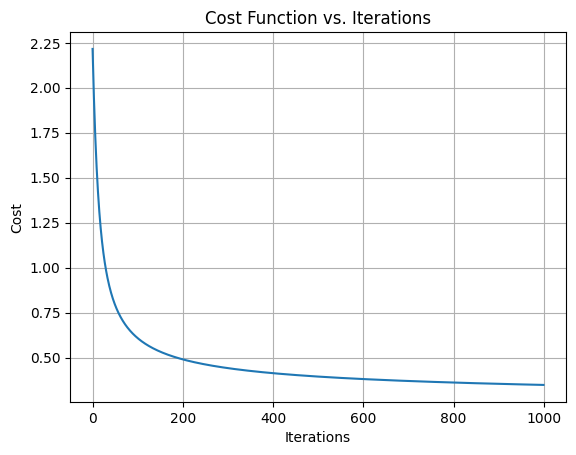

In [10]:
# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))
 # Number of features (784)
d = X_train.shape[1]
# Number of classes  (10)
c = y_train.shape[1]

# Initializing weights and biases
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha  = 0.1
n_iter = 1000

# Train
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

# Plot cost history
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Evaluate Model


Confusion Matrix:
[[1127    0    5    2    3   11    9    2   13    3]
 [   0 1276    7   11    1    5    1    4   16    1]
 [   1   16 1028   17   19    4   26   24   33    6]
 [   8    6   33 1051    1   53    9    8   29   21]
 [   1    5    7    1 1094    0   10    4    3   51]
 [  22   14   11   44   13  922   13    7   44   14]
 [   7    2   10    1   11   15 1119    2   10    0]
 [   7   26   25    5   16    2    0 1182    7   29]
 [   9   24   14   34    9   32   13    7 1003   15]
 [   9    6    9   18   44    9    0   39   10 1050]]
Precision : 0.90
Recall    : 0.90
F1-Score  : 0.90


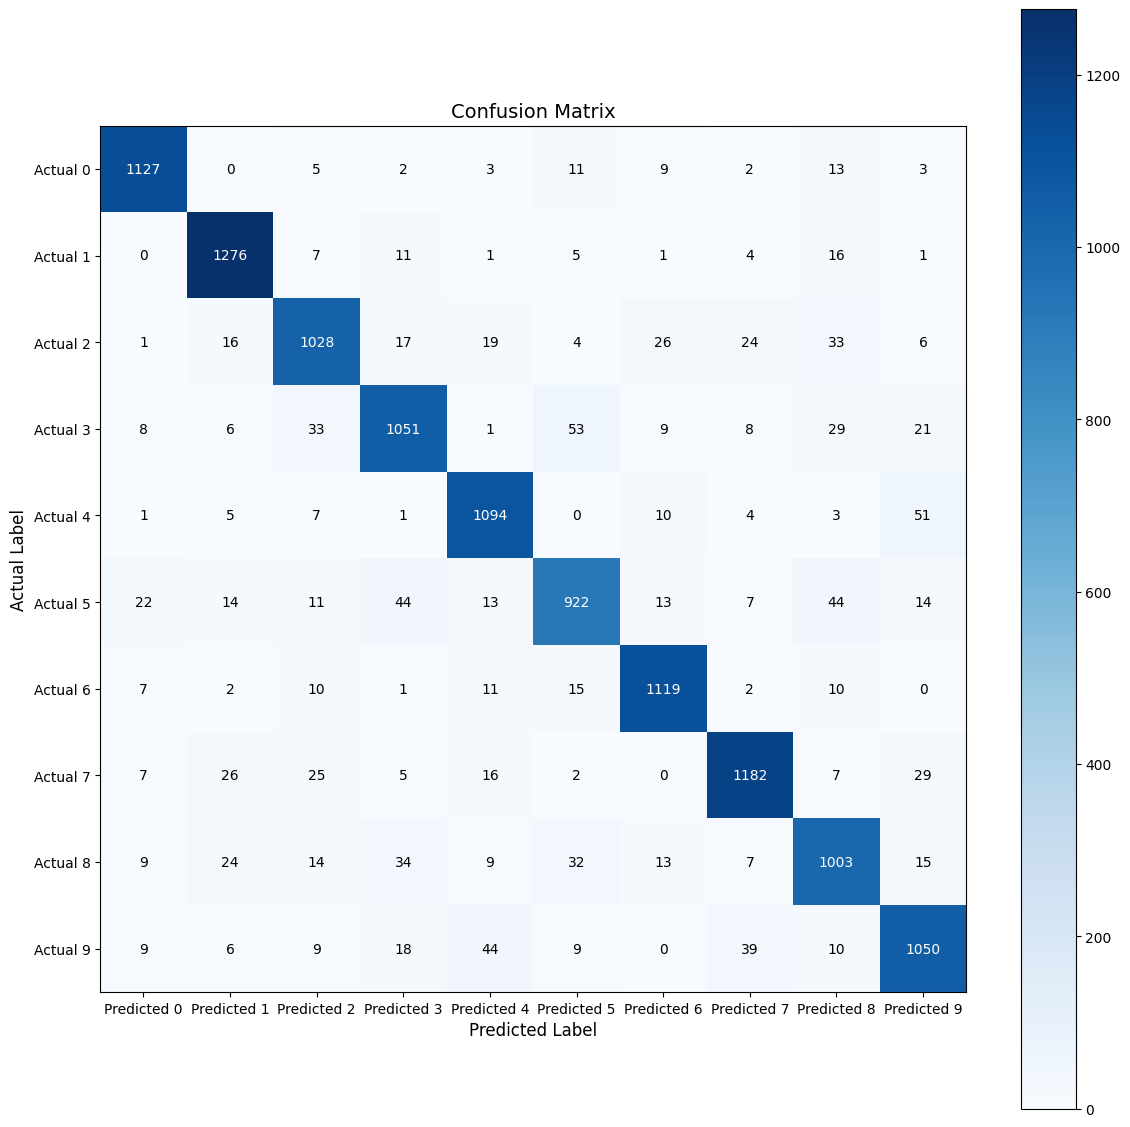

In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Predict and evaluate
y_pred_test  = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm)/2 else 'black')
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

Linear Separability

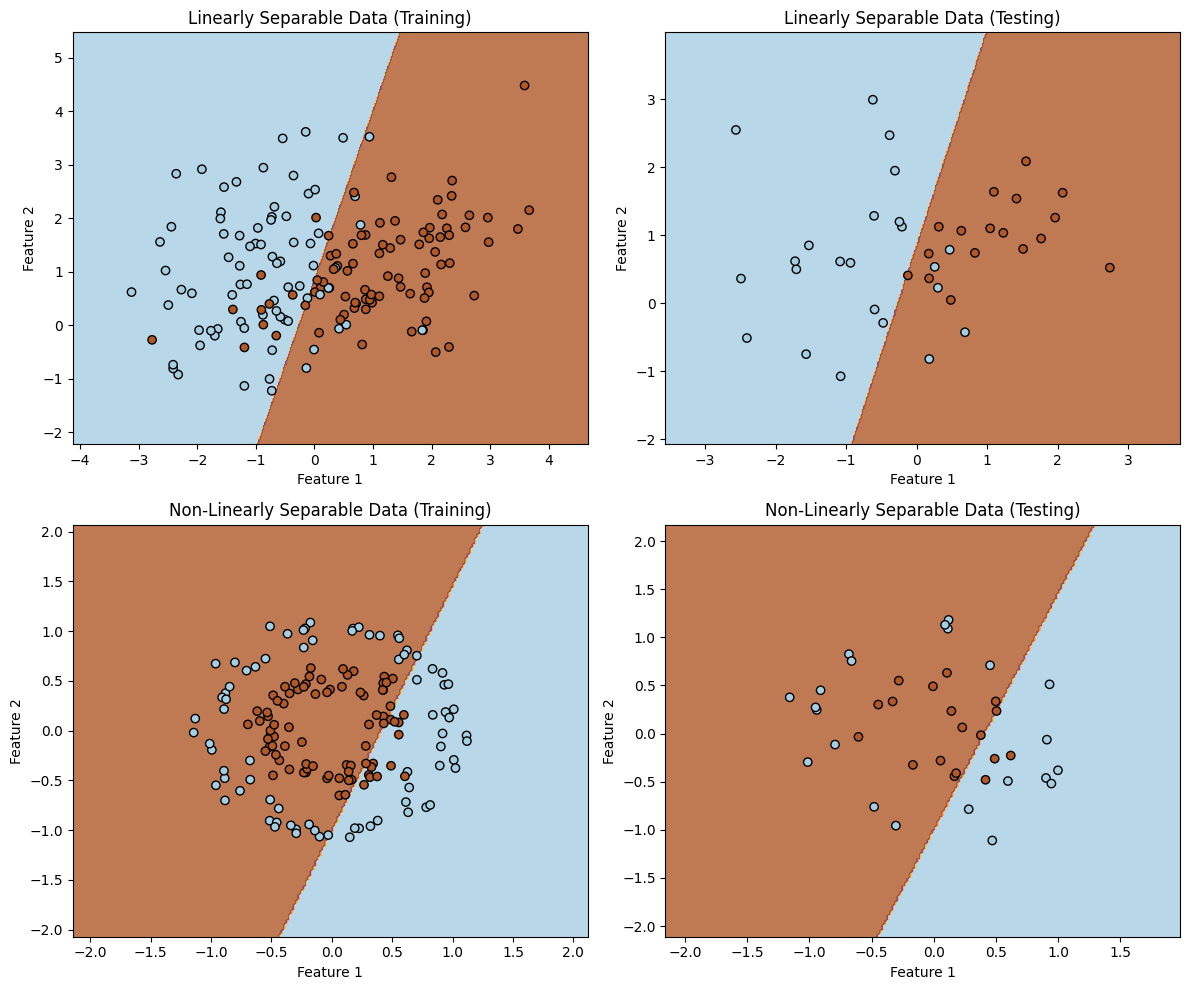

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
#Setting random
np.random.seed(42)

X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)
# Train logistic regression model on non-linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)
# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)
# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)
# Plot decision boundaries for linearly and non-linearly separable data
def plot_decision_boundary(ax, model, X, y, title):
  # step size in the mesh
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_decision_boundary(axes[0,0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear, 'Linearly Separable Data (Training)')
plot_decision_boundary(axes[0,1], logistic_model_linear_separable,
                       X_test_linear,  y_test_linear,  'Linearly Separable Data (Testing)')
plot_decision_boundary(axes[1,0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear, 'Non-Linearly Separable Data (Training)')
plot_decision_boundary(axes[1,1], logistic_model_non_linear_separable,
                       X_test_non_linear,  y_test_non_linear,  'Non-Linearly Separable Data (Testing)')
plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

**Question1. Is extracting pixel values sufficient for effective feature extraction? Why or why not?**  
Pixel values provide limited information as they tell us how bright or dark one tiny dot in the image is. The issue I see is that two people can write 7 completely differently as one person might slightly tilt and another might shift to left or bigger as all this difference look different for a model even if they are same digit.For MNIST it might work as the dataset is cleaned and image sizes are same but dealing with real handwritten notes or images taken from different angle,the pixel values would prvoide us poor results. Extracting curves and edges of eah digit might help to decribe the shape and prvoide meaningful information.



**Question2. Looking at four plots, the difference between datset was honestly quite obvious.**

Starting with the top two plots, which show the linearly separable data, the model did a really good job. There is a clear diagonal straight line cutting through the middle and it separates the blue dots from the brown dots quite well. The training plot on the top left and the testing plot on the top right look almost the same.It tells me the model didn't just memorise the training data but actually learned a proper boundary that works on new unseen data too.

Now looking at the bottom two plots, which show the non-linearly separable data, the situation is very different. The data here is actually arranged in a circular pattern where the two groups are mixed together in a way that no straight line can separate properly. But the model still drew a straight diagonal line, just like it did for the top plots. You can clearly see in both the training and testing plots that a large chunk of the blue dots are sitting inside the brown region and vice versa. The model is basically getting a lot of predictions wrong because it is forced to use a straight line on data that needs a curved boundary.

This really shows the core limitation of logistic regression as it can only ever draw straight lines. It works great when the data can actually be separated that way, but it completely falls apart when the data has a more complex shape like circles or curves.


**Question 3 — Challenges faced while implementing the code:**

Since the code had provide blue print on how it should work, which make it preety easy but undertsnading what was happeing was bit time consuming and confusing.
The part that I had to think about the most was the decision boundary function. At first I wasn't completely sure what the coloured regions in the plot represented. After looking at it more carefully I understood that the colours show what class the model would predict for every possible point in that space, not just the points in the dataset.

The other thing that made me think was seeing how badly logistic regression performed on the circles data. I initially thought maybe the model just needed more data or better settings, but then I realised the problem is more fundamental. Logistic regression is built to find straight line boundaries and that's all it can ever do. The circles problem needs a curved boundary and no amount of tuning will fix that. That was actually a useful thing to learn from this exercise.